# FINE TUNING


**Modelo base:** `dccuchile/distilbert-base-spanish-uncased` (DistilBETO)

**Tarea:** Clasificación combinada tipo de lugar + polaridad (Líneas A + B)

**Clases (9):** parque/restaurante/alojamiento × positivo/neutro/negativo

**División:** 70% train / 15% val / 15% test — seed fijo para reproducibilidad

In [1]:
import sys
sys.path.append('../modelos')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.modelos.finetuning_utils import (
    preparar_dataset,
    dividir_dataset,
    ResenasDataset,
    entrenar_modelo,
    evaluar_modelo,
    evaluar_baseline_zeroshot,
    clasificar_texto,
    cargar_modelo_entrenado,
    ETIQUETAS, LABEL2ID, ID2LABEL, MODELO_BASE
)
from transformers import AutoTokenizer

C:\Users\eveca\OneDrive\Escritorio\Chat TurisPOS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cargar el corpus

In [2]:
corpus = pd.read_csv('../../data/processed/corpus_final.csv')

print(f'Total reseñas: {len(corpus)}')
print(f'Columnas: {corpus.columns.tolist()}')
corpus[['lugar', 'categoria', 'polaridad', 'comentarios_espanol']].head(3)

Total reseñas: 5063
Columnas: ['lugar', 'texto', 'calificacion', 'categoria', 'fuente', 'idioma_comentario', 'comentarios_espanol', 'emojis', 'polaridad']


,lugar,categoria,polaridad,comentarios_espanol
0,Playa Manuel Antonio,parque,positivo,La playa de Manuel Antonio es absolutamente im...
1,Playa Manuel Antonio,parque,positivo,Una de las dos playas que están separadas en e...
2,Playa Manuel Antonio,parque,positivo,Playa excepcional a la que sólo se puede acced...


## 2. Preparar el dataset

In [3]:
df_preparado = preparar_dataset(corpus)
df_preparado.head(5)

Total muestras válidas: 4941

Distribución de etiquetas:
label_str
parque_positivo         1847
alojamiento_positivo    1535
restaurante_positivo     933
restaurante_negativo     150
parque_negativo          130
parque_neutro            118
restaurante_neutro        87
alojamiento_neutro        72
alojamiento_negativo      69
Name: count, dtype: int64


,texto,label,label_str
0,La playa de Manuel Antonio es absolutamente im...,0,parque_positivo
1,Una de las dos playas que están separadas en e...,0,parque_positivo
2,Playa excepcional a la que sólo se puede acced...,0,parque_positivo
3,"Para cualquier turista o incluso local, MAB es...",0,parque_positivo
4,"Bonita playa pero no la más bonita del país, h...",0,parque_positivo


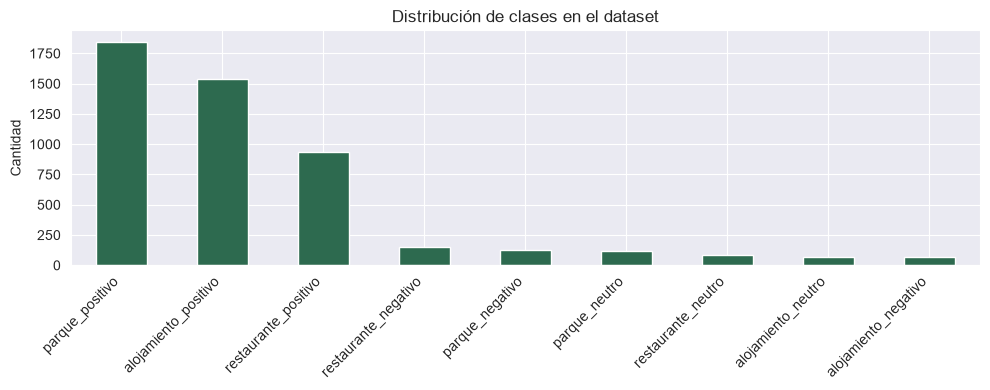

In [4]:
# Visualizar distribución de clases
fig, ax = plt.subplots(figsize=(10, 4))
df_preparado['label_str'].value_counts().plot(kind='bar', ax=ax, color='#2D6A4F')
ax.set_title('Distribución de clases en el dataset')
ax.set_xlabel('')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Dividir en train / val / test (70/15/15)

In [5]:
train_df, val_df, test_df = dividir_dataset(df_preparado)

print(f'\nTotal: {len(df_preparado)} muestras')

Train : 3458 muestras
Val   : 741 muestras
Test  : 742 muestras

Total: 4941 muestras


## 4. Tokenizar

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODELO_BASE)

train_dataset = ResenasDataset(train_df, tokenizer)
val_dataset   = ResenasDataset(val_df,   tokenizer)
test_dataset  = ResenasDataset(test_df,  tokenizer)

print(f'Train dataset: {len(train_dataset)} muestras')
print(f'Val dataset  : {len(val_dataset)} muestras')
print(f'Test dataset : {len(test_dataset)} muestras')

Train dataset: 3458 muestras
Val dataset  : 741 muestras
Test dataset : 742 muestras


## 5. Baseline zero-shot (antes del fine-tuning)

In [8]:
baseline = evaluar_baseline_zeroshot(test_df)
print(f'\nEste es el punto de partida — el fine-tuning debe superar estos números.')

=== BASELINE ZERO-SHOT (clase más frecuente) ===
Accuracy : 0.3733
F1 Macro : 0.0604
Clase predicha siempre: parque_positivo

Este es el punto de partida — el fine-tuning debe superar estos números.


## 6. Fine-tuning de DistilBETO

In [9]:
modelo, tokenizer, trainer = entrenar_modelo(train_dataset, val_dataset)

Cargando tokenizer y modelo base: dccuchile/distilbert-base-spanish-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 23731.49it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: dccuchile/distilbert-base-spanish-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_projector.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Iniciando entrenamiento...


C:\Users\eveca\OneDrive\Escritorio\Chat TurisPOS\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.693893,0.581580,0.829960,0.490806
2,0.409506,0.499380,0.840756,0.496319
3,0.315618,0.492885,0.852901,0.521003


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.98it/s]
C:\Users\eveca\OneDrive\Escritorio\Chat TurisPOS\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.51it/s]
C:\Users\eveca\OneDrive\Escritorio\Chat TurisPOS\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.21it/s]


Entrenamiento completado.


## 7. Evaluación sobre el conjunto de test

In [10]:
metricas, preds = evaluar_modelo(trainer, test_dataset, test_df)

Evaluando sobre conjunto de test...


C:\Users\eveca\OneDrive\Escritorio\Chat TurisPOS\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Accuracy : 0.8342
F1 Macro : 0.5629

Reporte de clasificación:
                      precision    recall  f1-score   support

     parque_positivo       0.83      0.94      0.88       277
       parque_neutro       0.60      0.17      0.26        18
     parque_negativo       0.48      0.60      0.53        20
restaurante_positivo       0.85      0.80      0.82       140
  restaurante_neutro       0.00      0.00      0.00        13
restaurante_negativo       0.48      0.52      0.50        23
alojamiento_positivo       0.92      0.92      0.92       230
  alojamiento_neutro       0.57      0.36      0.44        11
alojamiento_negativo       0.86      0.60      0.71        10

            accuracy                           0.83       742
           macro avg       0.62      0.54      0.56       742
        weighted avg       0.82      0.83      0.82       742


Métricas guardadas en src/resultados/metricas_finetuning.json


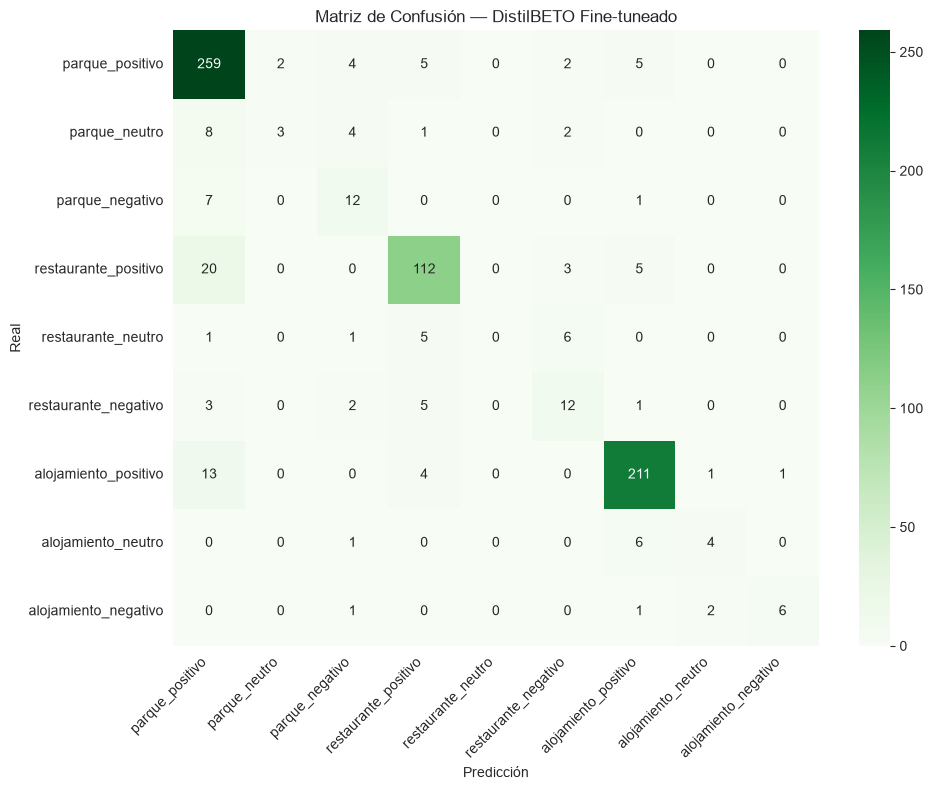

In [11]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns

matriz = confusion_matrix(test_df['label'].tolist(), preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Greens',
            xticklabels=ETIQUETAS, yticklabels=ETIQUETAS, ax=ax)
ax.set_title('Matriz de Confusión — DistilBETO Fine-tuneado')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Comparación Fine-tuning vs Baseline

In [12]:
print('=== COMPARACIÓN FINAL ===')
print(f"{'Métrica':<15} {'Baseline':>12} {'Fine-tuned':>12} {'Ganancia':>10}")
print('-' * 52)
for metrica in ['accuracy', 'f1_macro']:
    base_val = baseline[metrica]
    ft_val   = metricas[metrica]
    ganancia = ft_val - base_val
    print(f"{metrica:<15} {base_val:>12.4f} {ft_val:>12.4f} {ganancia:>+10.4f}")

=== COMPARACIÓN FINAL ===
Métrica             Baseline   Fine-tuned   Ganancia
----------------------------------------------------
accuracy              0.3733       0.8342    +0.4609
f1_macro              0.0604       0.5629    +0.5025


## 9. Guardar el modelo

In [13]:
import os
os.makedirs('../../models/clasificador_turismo', exist_ok=True)

modelo.save_pretrained('../../models/clasificador_turismo')
tokenizer.save_pretrained('../../models/clasificador_turismo')

print('Modelo guardado en models/clasificador_turismo/')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.17it/s]

Modelo guardado en models/clasificador_turismo/


## 10. Prueba de inferencia con el modelo entrenado

In [14]:
textos_prueba = [
    'El parque es increíble, la naturaleza es espectacular y los guías son excelentes.',
    'El servicio del hotel fue pésimo, la habitación estaba sucia y el personal fue grosero.',
    'El restaurante tiene una comida aceptable, nada extraordinario.',
    'Corcovado es una experiencia única, wildlife increíble y guías muy conocedores.',
    'La atención en el alojamiento fue regular, ni buena ni mala.',
]

modelo_cargado, tokenizer_cargado = cargar_modelo_entrenado('../../models/clasificador_turismo')

print('=== PRUEBA DE INFERENCIA ===')
for texto in textos_prueba:
    resultado = clasificar_texto(texto, modelo_cargado, tokenizer_cargado)
    print(f'\nTexto: {texto[:70]}...')
    print(f'  → Categoría : {resultado["categoria"]}')
    print(f'  → Polaridad : {resultado["polaridad"]}')
    print(f'  → Confianza : {resultado["confianza"]:.2%}')

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6994.88it/s]


=== PRUEBA DE INFERENCIA ===

Texto: El parque es increíble, la naturaleza es espectacular y los guías son ...
  → Categoría : parque
  → Polaridad : positivo
  → Confianza : 98.70%

Texto: El servicio del hotel fue pésimo, la habitación estaba sucia y el pers...
  → Categoría : alojamiento
  → Polaridad : neutro
  → Confianza : 40.75%

Texto: El restaurante tiene una comida aceptable, nada extraordinario....
  → Categoría : restaurante
  → Polaridad : positivo
  → Confianza : 94.41%

Texto: Corcovado es una experiencia única, wildlife increíble y guías muy con...
  → Categoría : parque
  → Polaridad : positivo
  → Confianza : 98.81%

Texto: La atención en el alojamiento fue regular, ni buena ni mala....
  → Categoría : alojamiento
  → Polaridad : positivo
  → Confianza : 88.18%


In [1]:
from transformers import AutoTokenizer

# Cargar el tokenizer original del modelo base y guardarlo completo
tokenizer_base = AutoTokenizer.from_pretrained(
    'dccuchile/distilbert-base-spanish-uncased',
    use_fast=False
)
tokenizer_base.save_pretrained('../../models/clasificador_turismo')
print('Tokenizer guardado correctamente')

C:\Users\eveca\OneDrive\Escritorio\Chat TurisPOS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer guardado correctamente


In [2]:
import os
archivos = os.listdir('../../models/clasificador_turismo')
print(archivos)

['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [3]:
from transformers import BertTokenizer

# Usar BertTokenizer directamente en lugar de AutoTokenizer
tokenizer_bert = BertTokenizer.from_pretrained(
    'dccuchile/distilbert-base-spanish-uncased'
)
tokenizer_bert.save_pretrained('../../models/clasificador_turismo')
print('Archivos guardados:', os.listdir('../../models/clasificador_turismo'))

Archivos guardados: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [4]:
import json

# Ver qué tiene el config.json actual
with open('../../models/clasificador_turismo/config.json', 'r') as f:
    config = json.load(f)
print(config)

{'activation': 'gelu', 'architectures': ['DistilBertForSequenceClassification'], 'attention_dropout': 0.1, 'bos_token_id': None, 'dim': 768, 'dropout': 0.1, 'dtype': 'float32', 'eos_token_id': None, 'hidden_dim': 3072, 'id2label': {'0': 'parque_positivo', '1': 'parque_neutro', '2': 'parque_negativo', '3': 'restaurante_positivo', '4': 'restaurante_neutro', '5': 'restaurante_negativo', '6': 'alojamiento_positivo', '7': 'alojamiento_neutro', '8': 'alojamiento_negativo'}, 'initializer_range': 0.02, 'label2id': {'alojamiento_negativo': 8, 'alojamiento_neutro': 7, 'alojamiento_positivo': 6, 'parque_negativo': 2, 'parque_neutro': 1, 'parque_positivo': 0, 'restaurante_negativo': 5, 'restaurante_neutro': 4, 'restaurante_positivo': 3}, 'max_position_embeddings': 512, 'model_type': 'distilbert', 'n_heads': 12, 'n_layers': 6, 'pad_token_id': 0, 'problem_type': 'single_label_classification', 'qa_dropout': 0.1, 'seq_classif_dropout': 0.2, 'sinusoidal_pos_embds': True, 'tie_weights_': True, 'tie_word

In [5]:
config['model_type'] = 'distilbert'

with open('../../models/clasificador_turismo/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Config reparado')
print(config)

Config reparado
{'activation': 'gelu', 'architectures': ['DistilBertForSequenceClassification'], 'attention_dropout': 0.1, 'bos_token_id': None, 'dim': 768, 'dropout': 0.1, 'dtype': 'float32', 'eos_token_id': None, 'hidden_dim': 3072, 'id2label': {'0': 'parque_positivo', '1': 'parque_neutro', '2': 'parque_negativo', '3': 'restaurante_positivo', '4': 'restaurante_neutro', '5': 'restaurante_negativo', '6': 'alojamiento_positivo', '7': 'alojamiento_neutro', '8': 'alojamiento_negativo'}, 'initializer_range': 0.02, 'label2id': {'alojamiento_negativo': 8, 'alojamiento_neutro': 7, 'alojamiento_positivo': 6, 'parque_negativo': 2, 'parque_neutro': 1, 'parque_positivo': 0, 'restaurante_negativo': 5, 'restaurante_neutro': 4, 'restaurante_positivo': 3}, 'max_position_embeddings': 512, 'model_type': 'distilbert', 'n_heads': 12, 'n_layers': 6, 'pad_token_id': 0, 'problem_type': 'single_label_classification', 'qa_dropout': 0.1, 'seq_classif_dropout': 0.2, 'sinusoidal_pos_embds': True, 'tie_weights_':